In [16]:
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
# 1. Configuration Constants (from Paper/SI)
W_I = 8.3e-4  # Average metabolic weight
W_R = 0.17    # Ribosomal weight
PHI_Q = 0.45  # Housekeeping offset
PHI_R0 = 0.066 # Ribosomal offset
PHI_MAX = 1 - PHI_Q - PHI_R0 # Total allocatable budget (~0.484)

# Reaction IDs for iJO1366
BIOMASS_ID = "BIOMASS_Ec_iJO1366_core_53p95M"
GLC_ID = "EX_glc__D_e"
PFK_ID = "PFK" # EMP Pathway marker
EDD_ID = "EDD" # ED Pathway marker

In [14]:
df_final = pd.read_csv("cafba_sweep_results.csv", index_col=0)

In [15]:
df_final

,w_c,growth_rate,phi_C,phi_E,phi_R,flux_PFK,flux_EDD,flux_glc
0,0.000000,0.726508,0.000000,0.361220,0.189506,4.229653,0.0,7.544269
1,0.000102,0.725317,0.000769,0.360653,0.189304,4.222810,0.0,7.532124
2,0.000210,0.724060,0.001580,0.360053,0.189090,4.215579,0.0,7.519292
3,0.000331,0.722665,0.002481,0.359389,0.188853,4.207559,0.0,7.505059
4,0.000469,0.721064,0.003515,0.358625,0.188581,4.198353,0.0,7.488721
...,...,...,...,...,...,...,...,...
95,0.884379,0.037022,0.444994,0.032750,0.072294,0.260747,0.0,0.503171
96,0.912397,0.035579,0.445925,0.032063,0.072048,0.243841,0.0,0.488740
97,0.941002,0.034185,0.446828,0.031395,0.071811,0.240763,0.0,0.474843
98,0.970201,0.032841,0.447698,0.030751,0.071583,0.231301,0.0,0.461449


Text(0.5, 1.0, 'Proteome Sector Allocation')

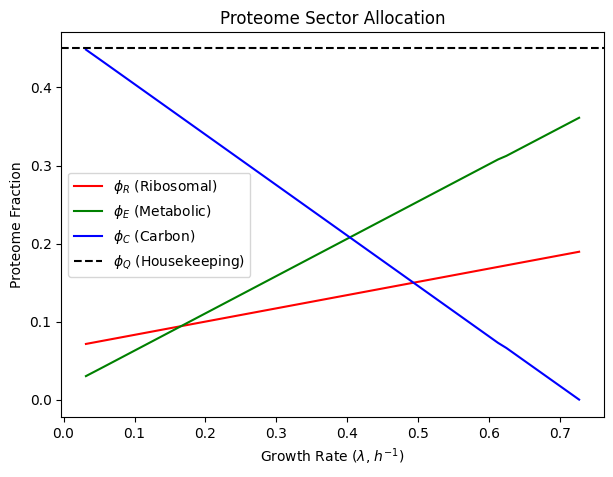

In [19]:
plt.figure(figsize=(7, 5))
plt.plot(df_final['growth_rate'], df_final['phi_R'], color='red', label='$\phi_R$ (Ribosomal)')
plt.plot(df_final['growth_rate'], df_final['phi_E'], color='green', label='$\phi_E$ (Metabolic)')
plt.plot(df_final['growth_rate'], df_final['phi_C'], color='blue', label='$\phi_C$ (Carbon)')
plt.axhline(y=PHI_Q, color='black', linestyle='--', label='$\phi_Q$ (Housekeeping)')
plt.xlabel('Growth Rate ($\lambda$, $h^{-1}$)')
plt.ylabel('Proteome Fraction')
plt.legend()
plt.title('Proteome Sector Allocation')

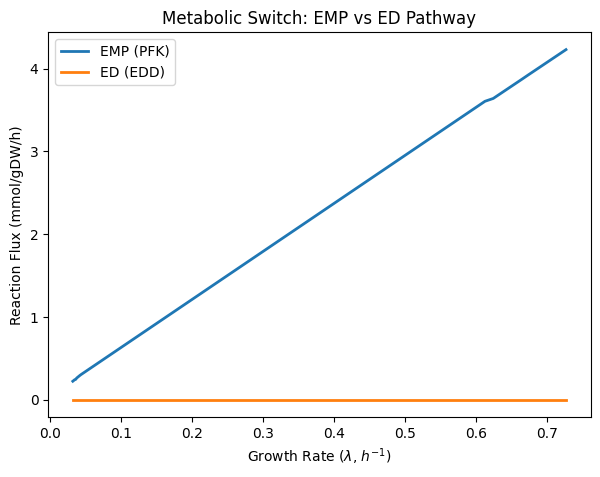

In [20]:
plt.figure(figsize=(7, 5))
plt.plot(df_final['growth_rate'], df_final['flux_PFK'], label='EMP (PFK)', linewidth=2)
plt.plot(df_final['growth_rate'], df_final['flux_EDD'], label='ED (EDD)', linewidth=2)
plt.xlabel('Growth Rate ($\lambda$, $h^{-1}$)')
plt.ylabel('Reaction Flux (mmol/gDW/h)')
plt.title('Metabolic Switch: EMP vs ED Pathway')
plt.legend()